Now, could you also extract the following information from ALL the jobs posted in the last 24 hours, on top of the information you have already obtained? 
- Date and Time of posting
- plot a graph of number of jobs against time of day (hour). Export this in .png
- For the fulltime/parttime classification, could you clean the unnecessary text
away?
- Get the URL of the company. At this step, try figuring out how to spot mycareerfuture. You will likely only notice this when using Selenium.
- Get the job classification and sub-classification

# Beautiful Soup

Import libraries

In [51]:
import requests 
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import re

job_list = []

# Clean the job type text (e.g., "This is a Full-time job" becomes "Full-time")
def clean_job_type(job_type_text):
    job_type_cleaned = re.sub(r'This is a (.*) job', r'\1', job_type_text)
    return job_type_cleaned.strip()

# Function to convert relative time to absolute datetime
def parse_relative_time(relative_time):
    current_time = datetime.now()
    
    if "m ago" in relative_time:
        minutes_ago = int(relative_time.replace("m ago", "").strip())
        return current_time - timedelta(minutes=minutes_ago)
    elif "h ago" in relative_time:
        hours_ago = int(relative_time.replace("h ago", "").strip())
        return current_time - timedelta(hours=hours_ago)
    else:
        return None  # We don't handle "days ago" or "weeks ago" now

# Extract job data from the page
def get_jobs_from_page(page_num):
    URL = f"https://sg.jobstreet.com/jobs?page={page_num}&sortmode=ListedDate"
    page = requests.get(URL)
    soup = BeautifulSoup(page.content, "html.parser")
    job_list = []
    job_cards = soup.find_all(attrs={"data-testid": "job-card"})
    
    for job in job_cards:
        job_title_text = job.get('aria-label')
        job_id = job.get('data-job-id')

        company_tag = job.find(attrs={'data-automation': 'jobCompany'})
        company_name_text = company_tag.text.strip() if company_tag else 'N/A'

        salary_tag = job.find(attrs={'data-automation': 'jobSalary'})
        salary_range = salary_tag.text.strip() if salary_tag else 'N/A'

        job_type_tag = job.find('p')
        job_type = job_type_tag.text.strip() if job_type_tag else 'N/A'
        job_type = clean_job_type(job_type)

        location_tags = job.find_all(attrs={'data-automation': 'jobCardLocation'})
        job_locations = [loc.get_text(strip=True) for loc in location_tags]

        listing_date_tag = job.find(attrs={'data-automation': 'jobListingDate'})
        listing_date = listing_date_tag.text.strip() if listing_date_tag else 'N/A'

        # Convert relative time to actual datetime
        post_datetime = parse_relative_time(listing_date)
        
        # Only consider jobs posted within the last 24 hours
        if post_datetime and post_datetime >= datetime.now() - timedelta(days=1):
            classification_tag = job.find(attrs={'data-automation': 'jobClassification'})
            job_classification = classification_tag.text.strip() if classification_tag else 'N/A'

            subclassification_tag = job.find(attrs={'data-automation': 'jobSubClassification'})
            job_subclassification = subclassification_tag.text.strip() if subclassification_tag else 'N/A'

            job_list.append({
                'Job Title': job_title_text,
                'Job ID': job_id,
                'Company': company_name_text,
                'Salary Range': salary_range,
                'Job Type': job_type,
                'Job Locations': job_locations,
                'Job Classification': job_classification,
                'Job Sub Classification': job_subclassification,
                'Listing Time Since': listing_date,
                'Actual Posted DateTime': post_datetime
            })
            
    return job_list



In [52]:
# Main loop to scrape all jobs within 24 hours
page_num = 1
while True:
    jobs = get_jobs_from_page(page_num)
    
    if not jobs:
        print("No more jobs found on this page.")
        break
    
    job_list.extend(jobs)
    page_num += 1

No more jobs found on this page.


In [53]:
# Convert the list of jobs to a DataFrame
df = pd.DataFrame(job_list)

# Check how many jobs were fetched
print(f"Fetched {len(df)} jobs in the last 24 hours")

df.head(5)

Fetched 2378 jobs in the last 24 hours


,Job Title,Job ID,Company,Salary Range,Job Type,Job Locations,Job Classification,Job Sub Classification,Listing Time Since,Actual Posted DateTime
0,Hiring for Solutions Architect- Data warehouse,82662747,Path Infotech Pte Ltd,"$8,000 – $9,500 per month",Contract/Temp,"[Singapore River, ,Central Region]",(Information & Communication Technology),Architects,1m ago,2025-03-10 21:25:41.484825
1,Full Stack Engineer (Kyber Life Pte. Ltd.),82662671,Private Advertiser,N/A,Full time,[Central Region],(Information & Communication Technology),Developers/Programmers,10m ago,2025-03-10 21:16:41.484825
2,"Accounts Executive (Full Set | AP, AR, GL) - U...",82662669,Search Personnel Pte Ltd,"$3,500 – $4,500 per month",Full time,[Central Region],(Accounting),Accounts Officers/Clerks,10m ago,2025-03-10 21:16:41.484825
3,Logistics Senior Executive / Manager,82662636,KOI THÉ SINGAPORE PTE LTD,N/A,Full time,"[Serangoon North, ,North-East Region]","(Manufacturing, Transport & Logistics)","Warehousing, Storage & Distribution",14m ago,2025-03-10 21:12:41.484825
4,Production Supervisor (ID: 648775) | AL,82662606,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$4,000 – $5,000 per month",Full time,"[Tampines, ,East Region]","(Manufacturing, Transport & Logistics)",Team Leaders/Supervisors,18m ago,2025-03-10 21:08:41.484825


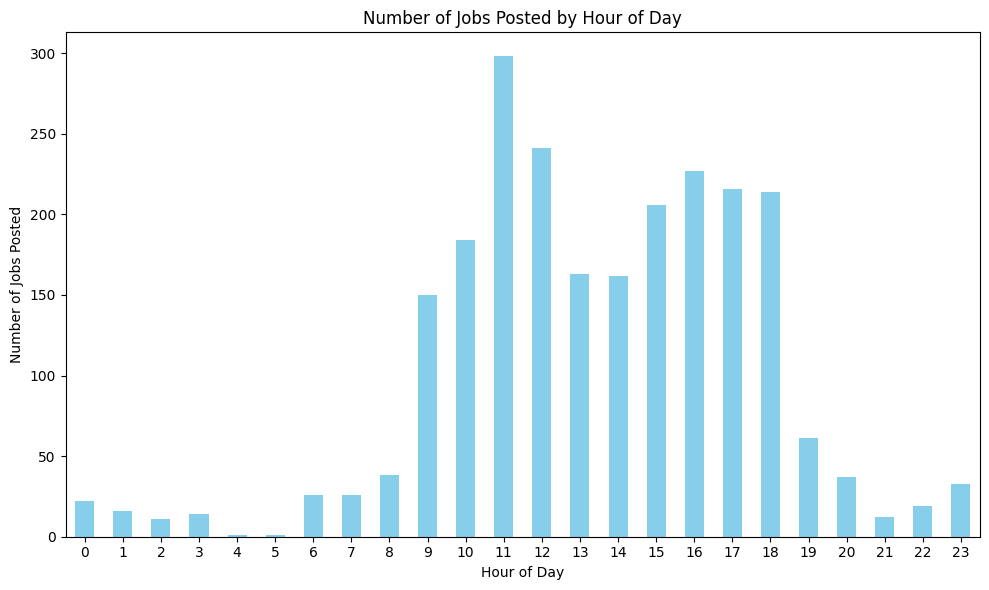

In [54]:
# Plot the number of jobs posted by hour of the day
df['Hour Posted'] = df['Actual Posted DateTime'].dt.hour
hourly_jobs = df.groupby('Hour Posted').size()

plt.figure(figsize=(10, 6))
hourly_jobs.plot(kind='bar', color='skyblue')
plt.title('Number of Jobs Posted by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Jobs Posted')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cyx_bar_graph_of_job_postings_by_hour.png')

In [55]:
# Export data to Excel
df.to_excel('cyx_jobstreet_jobs_last_24_hours.xlsx', index=False)

# Selenium

import libraries

In [45]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

import time
import pandas as pd
import re
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# Setup Selenium WebDriver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()))

In [46]:
# Clean the job type text (e.g., "This is a Full-time job" becomes "Full-time")
def clean_job_type(job_type_text):
    job_type_cleaned = re.sub(r'This is a (.*) job', r'\1', job_type_text)
    return job_type_cleaned.strip()

# Function to convert relative time to absolute datetime
def parse_relative_time(relative_time):
    current_time = datetime.now()
    
    if "m ago" in relative_time:
        minutes_ago = int(relative_time.replace("m ago", "").strip())
        return current_time - timedelta(minutes=minutes_ago)
    elif "h ago" in relative_time:
        hours_ago = int(relative_time.replace("h ago", "").strip())
        return current_time - timedelta(hours=hours_ago)
    else:
        return None  # We don't handle "days ago" or "weeks ago" now
    
job_list = []

# Extract job data from the page
def get_jobs_from_page(page_num):
    URL = f"https://sg.jobstreet.com/jobs?page={page_num}&sortmode=ListedDate"
    
    # Open the webpage with Selenium
    driver.get(URL)
    
    # Give the page some time to load (you can use WebDriverWait for a more efficient wait)
    time.sleep(3)
    
    # Find all the job cards on the page
    job_list = []
    job_cards = driver.find_elements(By.CSS_SELECTOR, '[data-testid="job-card"]')
    
    # Extract information for each job card
    for job in job_cards:
        # Extract job title
        job_title_text = job.get_attribute('aria-label')
        
        # Extract job ID
        job_id = job.get_attribute('data-job-id')
        
        # Extract company name
        company_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobCompany"]')
        company_name_text = company_tag.text.strip() if company_tag else 'N/A'
        
        # Extract salary range
        salary_tag = WebDriverWait(driver, 10).until(
             EC.presence_of_element_located((By.CSS_SELECTOR, '[data-automation="jobSalary"]'))
             )
        salary_range = salary_tag.text.strip() if salary_tag else 'N/A'
        
        # Extract the job URL
        url_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="job-list-view-job-link"]')
        full_job_url = url_tag.get_attribute('href') if url_tag else 'N/A'
        
        # Extract Job Type or brief description
        job_type_tag = job.find_element(By.TAG_NAME, 'p')
        job_type = job_type_tag.text.strip() if job_type_tag else 'N/A'
        job_type = clean_job_type(job_type)
        
        # Extract Job Locations
        location_tags = job.find_elements(By.CSS_SELECTOR, '[data-automation="jobCardLocation"]')
        job_locations = [loc.text.strip() for loc in location_tags]

        # Extract Job Classification
        classification_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobClassification"]')
        job_classification = classification_tag.text.strip() if classification_tag else 'N/A'
        
        # Extract Job Sub-Classification
        subclassification_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobSubClassification"]')
        job_subclassification = subclassification_tag.text.strip() if subclassification_tag else 'N/A'

        
        # Extract Listing Date
        listing_date_tag = job.find_element(By.CSS_SELECTOR, '[data-automation="jobListingDate"]')
        listing_date = listing_date_tag.text.strip() if listing_date_tag else 'N/A'

        # Convert relative time to actual datetime
        post_datetime = parse_relative_time(listing_date)
        
        # Only consider jobs posted within the last 24 hours
        if post_datetime and post_datetime >= datetime.now() - timedelta(days=1):
            
            # Append the job data to the list
            job_list.append({
                'Job Title': job_title_text,
                'Job ID': job_id,
                'URL': full_job_url,
                'Company': company_name_text,
                'Salary Range': salary_range,
                'Job Type': job_type,
                'Job Locations': job_locations,                
                'Job Classification': job_classification,
                'Job Sub Classification': job_subclassification,
                'Listing Time Since': listing_date,
                'Actual Posted DateTime': post_datetime
            })
    
    return job_list


In [47]:
# Main loop to scrape all jobs within 24 hours
page_num = 1
while True:
    jobs = get_jobs_from_page(page_num)
    
    if not jobs:
        print("No more jobs found on this page.")
        break
    
    job_list.extend(jobs)
    page_num += 1

InvalidSessionIdException: Message: invalid session id: session deleted as the browser has closed the connection
from disconnected: not connected to DevTools
  (Session info: chrome=134.0.6998.35)
Stacktrace:
	GetHandleVerifier [0x002FCED3+25523]
	(No symbol) [0x002823B4]
	(No symbol) [0x001506E3]
	(No symbol) [0x0013FEC0]
	(No symbol) [0x0015DFDF]
	(No symbol) [0x001C46EF]
	(No symbol) [0x001DEB89]
	(No symbol) [0x001BD5F6]
	(No symbol) [0x0018C55F]
	(No symbol) [0x0018D8A4]
	GetHandleVerifier [0x00602713+3193843]
	GetHandleVerifier [0x006169E9+3276489]
	GetHandleVerifier [0x00610F0C+3253228]
	GetHandleVerifier [0x0039B0C0+673184]
	(No symbol) [0x0028B43D]
	(No symbol) [0x00288568]
	(No symbol) [0x00288709]
	(No symbol) [0x0027AE90]
	BaseThreadInitThunk [0x75CF7BA9+25]
	RtlInitializeExceptionChain [0x7786C28B+107]
	RtlClearBits [0x7786C20F+191]
	(No symbol) [0x00000000]


In [48]:
# Create a DataFrame from the collected job data
df = pd.DataFrame(job_list)

# Check how many jobs were fetched
print(f"Fetched {len(df)} jobs in the last 24 hours")

df.head(5)


Fetched 1632 jobs in the last 24 hours


,Job Title,Job ID,URL,Company,Salary Range,Job Type,Job Locations,Job Classification,Job Sub Classification,Listing Time Since,Actual Posted DateTime
0,Field Application / Technical Support (Failure...,82661731,https://sg.jobstreet.com/job/82661731?type=sta...,RRECRUITER PTE. LTD.,"$3,500 – $4,500 per month",Full time,[Central Region],(Engineering),Electrical/Electronic Engineering,7m ago,2025-03-10 20:17:38.313595
1,Automation Engineer,82661727,https://sg.jobstreet.com/job/82661727?type=sta...,MICRON SEMICONDUCTOR ASIA OPERATIONS PTE LTD,"$3,500 – $4,500 per month",Full time,[Central Region],(Engineering),Electrical/Electronic Engineering,7m ago,2025-03-10 20:17:38.549589
2,Warehouse Assistant,82661730,https://sg.jobstreet.com/job/82661730?type=sta...,Allinton Engineering & Trading Pte. Ltd.,"$3,500 – $4,500 per month",Full time,"[Tuas, , West Region]","(Manufacturing, Transport & Logistics)","Warehousing, Storage & Distribution",7m ago,2025-03-10 20:17:38.750846
3,Procurement Executive,80537643,https://sg.jobstreet.com/job/80537643?type=sta...,Private Advertiser,"$3,500 – $4,500 per month",Full time,[Central Region],"(Manufacturing, Transport & Logistics)","Purchasing, Procurement & Inventory",12m ago,2025-03-10 20:12:38.950690
4,"Administrative Support (Healthcare) $2700, One...",82661706,https://sg.jobstreet.com/job/82661706?type=sta...,PERSOLKELLY Singapore Pte Ltd (Formerly Kelly ...,"$3,500 – $4,500 per month",Full time,"[One North, , Central Region]",(Administration & Office Support),Administrative Assistants,15m ago,2025-03-10 20:09:39.167558


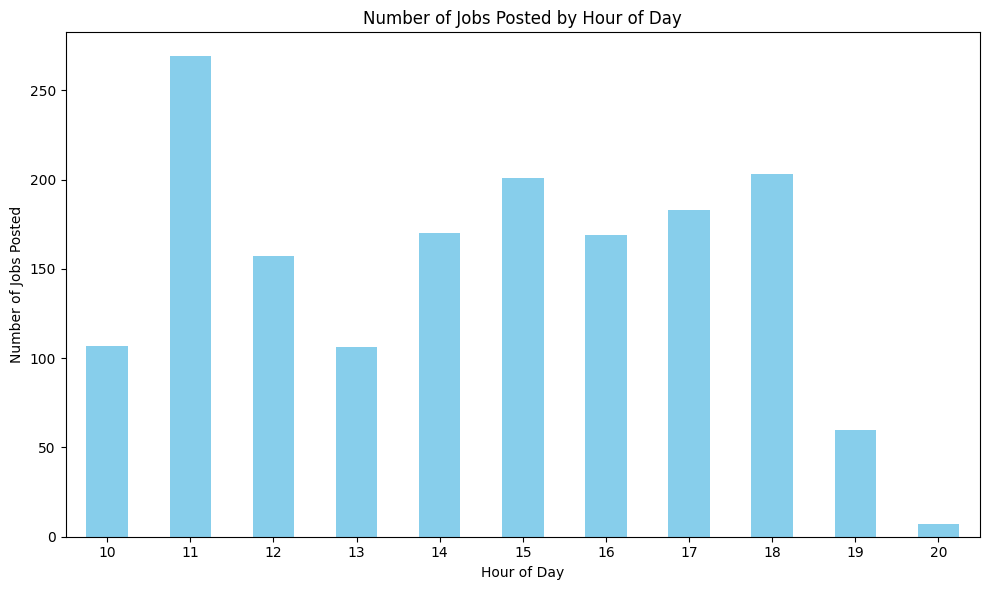

In [49]:
# Plot the number of jobs posted by hour of the day
df['Hour Posted'] = df['Actual Posted DateTime'].dt.hour  # Extract hour from datetime
hourly_jobs = df.groupby('Hour Posted').size()

plt.figure(figsize=(10, 6))
hourly_jobs.plot(kind='bar', color='skyblue')
plt.title('Number of Jobs Posted by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Jobs Posted')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('job_postings_by_hour_selenium.png')


In [50]:

# Export data to Excel
df.to_excel('cyx_jobstreet_jobs_last_24_hours_selenium.xlsx', index=False)